## Import Libraries

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import warnings
import os

warnings.filterwarnings('ignore')
os.chdir("/home/intern1/my_data/sm2rain-irrigation/NASA SMAP earthaccess")

print("Libraries imported successfully!")

Libraries imported successfully!


## Configuration

In [98]:
# Configuration parameters
DATA_FILE = Path('/home/intern1/my_data/sm2rain-irrigation/NASA SMAP earthaccess/extracted_data_new/SPL2SMAP_S_AMSR2_ROI_2020.csv')
PRECIP_FILE = Path('/home/intern1/my_data/sm2rain-irrigation/IMERG_ROI1_2020.csv')

# DBSCAN parameters
TOLERANCE = 0.01  # 0.01 degrees (~1.1 km)
MIN_SAMPLES = 10   # Minimum samples to form a cluster

# Date range for analysis
START_DATE = '2020-01-01'
STOP_DATE = '2020-12-31'

TARGET_LAT = 30.5    # Your latitude
TARGET_LON = 75.5    # Your longitude
SEARCH_TOLERANCE = 0.1  # Search radius in degrees

print(f"Configuration:")
print(f"  Data file: {DATA_FILE}")
print(f"  Precipitation file: {PRECIP_FILE}")
print(f"  DBSCAN tolerance: {TOLERANCE} degrees (~{TOLERANCE * 111:.2f} km)")

print(f"  DBSCAN min_samples: {MIN_SAMPLES}")
print(f"  Date range: {START_DATE} to {STOP_DATE}")

Configuration:
  Data file: /home/intern1/my_data/sm2rain-irrigation/NASA SMAP earthaccess/extracted_data_new/SPL2SMAP_S_AMSR2_ROI_2020.csv
  Precipitation file: /home/intern1/my_data/sm2rain-irrigation/IMERG_ROI1_2020.csv
  DBSCAN tolerance: 0.01 degrees (~1.11 km)
  DBSCAN min_samples: 10
  Date range: 2020-01-01 to 2020-12-31


## Load Data

In [99]:
# Load the CSV file
print(f"Loading data from: {DATA_FILE}")
print(f"File exists: {DATA_FILE.exists()}\n")

if not DATA_FILE.exists():
    raise FileNotFoundError(f"File not found: {DATA_FILE}")

# Read CSV
df = pd.read_csv(DATA_FILE)

print(f"Data loaded successfully!")
print(f"  Shape: {df.shape}")
print(f"  Columns: {list(df.columns)}")

# Convert time to datetime
df['time'] = pd.to_datetime(df['time'])

# Filter by date range
df = df[(df['time'] >= START_DATE) & (df['time'] <= STOP_DATE)]

print(f"\nAfter date filtering:")
print(f"  Total observations: {len(df):,}")
print(f"  Date range: {df['time'].min()} to {df['time'].max()}")
print(f"  Longitude range: {df['longitude'].min():.4f} to {df['longitude'].max():.4f}")
print(f"  Latitude range: {df['latitude'].min():.4f} to {df['latitude'].max():.4f}")
print(f"  Soil moisture range: {df['soil_moisture'].min():.4f} to {df['soil_moisture'].max():.4f}")

# Display first few rows
print(f"\nFirst 5 rows:")
print(df.head())

Loading data from: /home/intern1/my_data/sm2rain-irrigation/NASA SMAP earthaccess/extracted_data_new/SPL2SMAP_S_AMSR2_ROI_2020.csv
File exists: True

Data loaded successfully!
  Shape: (5602, 4)
  Columns: ['latitude', 'longitude', 'soil_moisture', 'time']

After date filtering:
  Total observations: 5,578
  Date range: 2020-01-01 20:49:59.400882 to 2020-12-30 21:14:07.785874
  Longitude range: 75.0061 to 76.0000
  Latitude range: 30.1122 to 30.9312
  Soil moisture range: 0.0083 to 0.5057

First 5 rows:
    latitude  longitude  soil_moisture                       time
0  30.846846  75.734060       0.202427 2020-01-01 20:49:59.400882
1  30.853730  75.498055       0.251905 2020-01-01 20:49:59.869018
2  30.837286  75.229330       0.261005 2020-01-01 20:50:00.883926
3  30.630564  75.754880       0.249319 2020-01-01 20:50:02.831113
4  30.622866  75.476280       0.268412 2020-01-01 20:50:03.615056


## Extract Unique Locations

In [100]:
# Get unique locations
unique_locations = df[['latitude', 'longitude']].drop_duplicates().reset_index(drop=True)

print(f"Unique Locations:")
print(f"  Total unique locations: {len(unique_locations):,}")
print(f"\nFirst 10 unique locations:")
print(unique_locations.head(10))

# Create coordinate array for DBSCAN
coords = unique_locations[['latitude', 'longitude']].values

print(f"\nCoordinate array shape: {coords.shape}")

Unique Locations:
  Total unique locations: 5,578

First 10 unique locations:
    latitude  longitude
0  30.846846  75.734060
1  30.853730  75.498055
2  30.837286  75.229330
3  30.630564  75.754880
4  30.622866  75.476280
5  30.622839  75.236595
6  30.392810  75.748200
7  30.402523  75.501210
8  30.395761  75.221794
9  30.183134  75.741870

Coordinate array shape: (5578, 2)


## Apply DBSCAN Clustering

In [101]:
# Apply DBSCAN clustering
print(f"Applying DBSCAN clustering...")
print(f"  eps (tolerance): {TOLERANCE} degrees")
print(f"  min_samples: {MIN_SAMPLES}")

# DBSCAN expects distance in the same units as coordinates
# eps is in degrees, which works for lat/lon
# metric='euclidean' works for small regions where lat/lon approximates Cartesian
dbscan = DBSCAN(eps=TOLERANCE, min_samples=MIN_SAMPLES, metric='euclidean')
unique_locations['cluster'] = dbscan.fit_predict(coords)

# Get clustering statistics
n_clusters = len(set(unique_locations['cluster'])) - (1 if -1 in unique_locations['cluster'] else 0)
n_noise = list(unique_locations['cluster']).count(-1)

print(f"\nClustering Results:")
print(f"  Number of clusters: {n_clusters}")
print(f"  Number of noise points: {n_noise}")
print(f"  Average points per cluster: {len(unique_locations) / max(n_clusters, 1):.2f}")

# Display cluster distribution
print(f"\nCluster sizes:")
cluster_counts = unique_locations['cluster'].value_counts().sort_index()
print(cluster_counts.head(20))

Applying DBSCAN clustering...
  eps (tolerance): 0.01 degrees
  min_samples: 10

Clustering Results:
  Number of clusters: 17
  Number of noise points: 43
  Average points per cluster: 328.12

Cluster sizes:
cluster
-1      43
 0     446
 1     445
 2     441
 3     444
 4     442
 5     429
 6     448
 7     443
 8     427
 9     446
 10    446
 11    424
 12     67
 13     72
 14     51
 15     64
Name: count, dtype: int64


## Calculate Cluster Centroids and Merge with Data

In [102]:
# Calculate cluster centroids
cluster_centroids = unique_locations[unique_locations['cluster'] != -1].groupby('cluster').agg({
    'latitude': 'mean',
    'longitude': 'mean'
}).reset_index()

cluster_centroids.columns = ['cluster', 'centroid_lat', 'centroid_lon']

print(f"Cluster Centroids:")
print(f"  Number of centroids: {len(cluster_centroids)}")
print(f"\nFirst 10 centroids:")
print(cluster_centroids.head(10))

# Merge cluster assignments back to original data
# First merge unique_locations with cluster info to df
df_with_clusters = df.merge(
    unique_locations[['latitude', 'longitude', 'cluster']], 
    on=['latitude', 'longitude'], 
    how='left'
)

print(f"\nData with cluster assignments:")
print(f"  Shape: {df_with_clusters.shape}")
print(f"  Clusters in data: {df_with_clusters['cluster'].nunique()}")
print(f"\nFirst 5 rows:")
print(df_with_clusters.head())

Cluster Centroids:
  Number of centroids: 16

First 10 centroids:
   cluster  centroid_lat  centroid_lon
0        0     30.851611     75.747919
1        1     30.850488     75.488182
2        2     30.850854     75.228275
3        3     30.624141     75.748545
4        4     30.624063     75.487483
5        5     30.624077     75.228707
6        6     30.397121     75.748524
7        7     30.397050     75.489274
8        8     30.396877     75.227423
9        9     30.171381     75.748470

Data with cluster assignments:
  Shape: (5578, 5)
  Clusters in data: 17

First 5 rows:
    latitude  longitude  soil_moisture                       time  cluster
0  30.846846  75.734060       0.202427 2020-01-01 20:49:59.400882        0
1  30.853730  75.498055       0.251905 2020-01-01 20:49:59.869018        1
2  30.837286  75.229330       0.261005 2020-01-01 20:50:00.883926        2
3  30.630564  75.754880       0.249319 2020-01-01 20:50:02.831113        3
4  30.622866  75.476280       0.268412 20

## Aggregate Soil Moisture by Cluster and Time

In [103]:
# Remove noise points (cluster = -1)
df_clustered = df_with_clusters[df_with_clusters['cluster'] != -1].copy()

print(f"Data after removing noise:")
print(f"  Total observations: {len(df_clustered):,}")
print(f"  Number of clusters: {df_clustered['cluster'].nunique()}")

# Aggregate soil moisture by cluster and time (daily average)
df_clustered['date'] = df_clustered['time'].dt.date

cluster_time_series = df_clustered.groupby(['cluster', 'date']).agg({
    'soil_moisture': ['mean', 'std', 'count']
}).reset_index()

cluster_time_series.columns = ['cluster', 'date', 'sm_mean', 'sm_std', 'count']
cluster_time_series['date'] = pd.to_datetime(cluster_time_series['date'])

print(f"\nAggregated Time Series:")
print(f"  Shape: {cluster_time_series.shape}")
print(f"  Clusters: {cluster_time_series['cluster'].nunique()}")
print(f"  Date range: {cluster_time_series['date'].min()} to {cluster_time_series['date'].max()}")
print(f"\nFirst 10 rows:")
print(cluster_time_series.head(10))

Data after removing noise:
  Total observations: 5,535
  Number of clusters: 16

Aggregated Time Series:
  Shape: (4474, 5)
  Clusters: 16
  Date range: 2020-01-01 00:00:00 to 2020-12-30 00:00:00

First 10 rows:
   cluster       date   sm_mean    sm_std  count
0        0 2020-01-01  0.202427       NaN      1
1        0 2020-01-02  0.172126       NaN      1
2        0 2020-01-03  0.165831  0.005949      2
3        0 2020-01-04  0.185318       NaN      1
4        0 2020-01-05  0.184240  0.019510      2
5        0 2020-01-06  0.224969       NaN      1
6        0 2020-01-07  0.242007       NaN      1
7        0 2020-01-08  0.252329       NaN      1
8        0 2020-01-09  0.224049       NaN      1
9        0 2020-01-10  0.234879       NaN      1
  Clusters: 16
  Date range: 2020-01-01 00:00:00 to 2020-12-30 00:00:00

First 10 rows:
   cluster       date   sm_mean    sm_std  count
0        0 2020-01-01  0.202427       NaN      1
1        0 2020-01-02  0.172126       NaN      1
2        0 202

## Plot Temporal Soil Moisture for All Clusters

Plotting temporal soil moisture for 16 clusters...


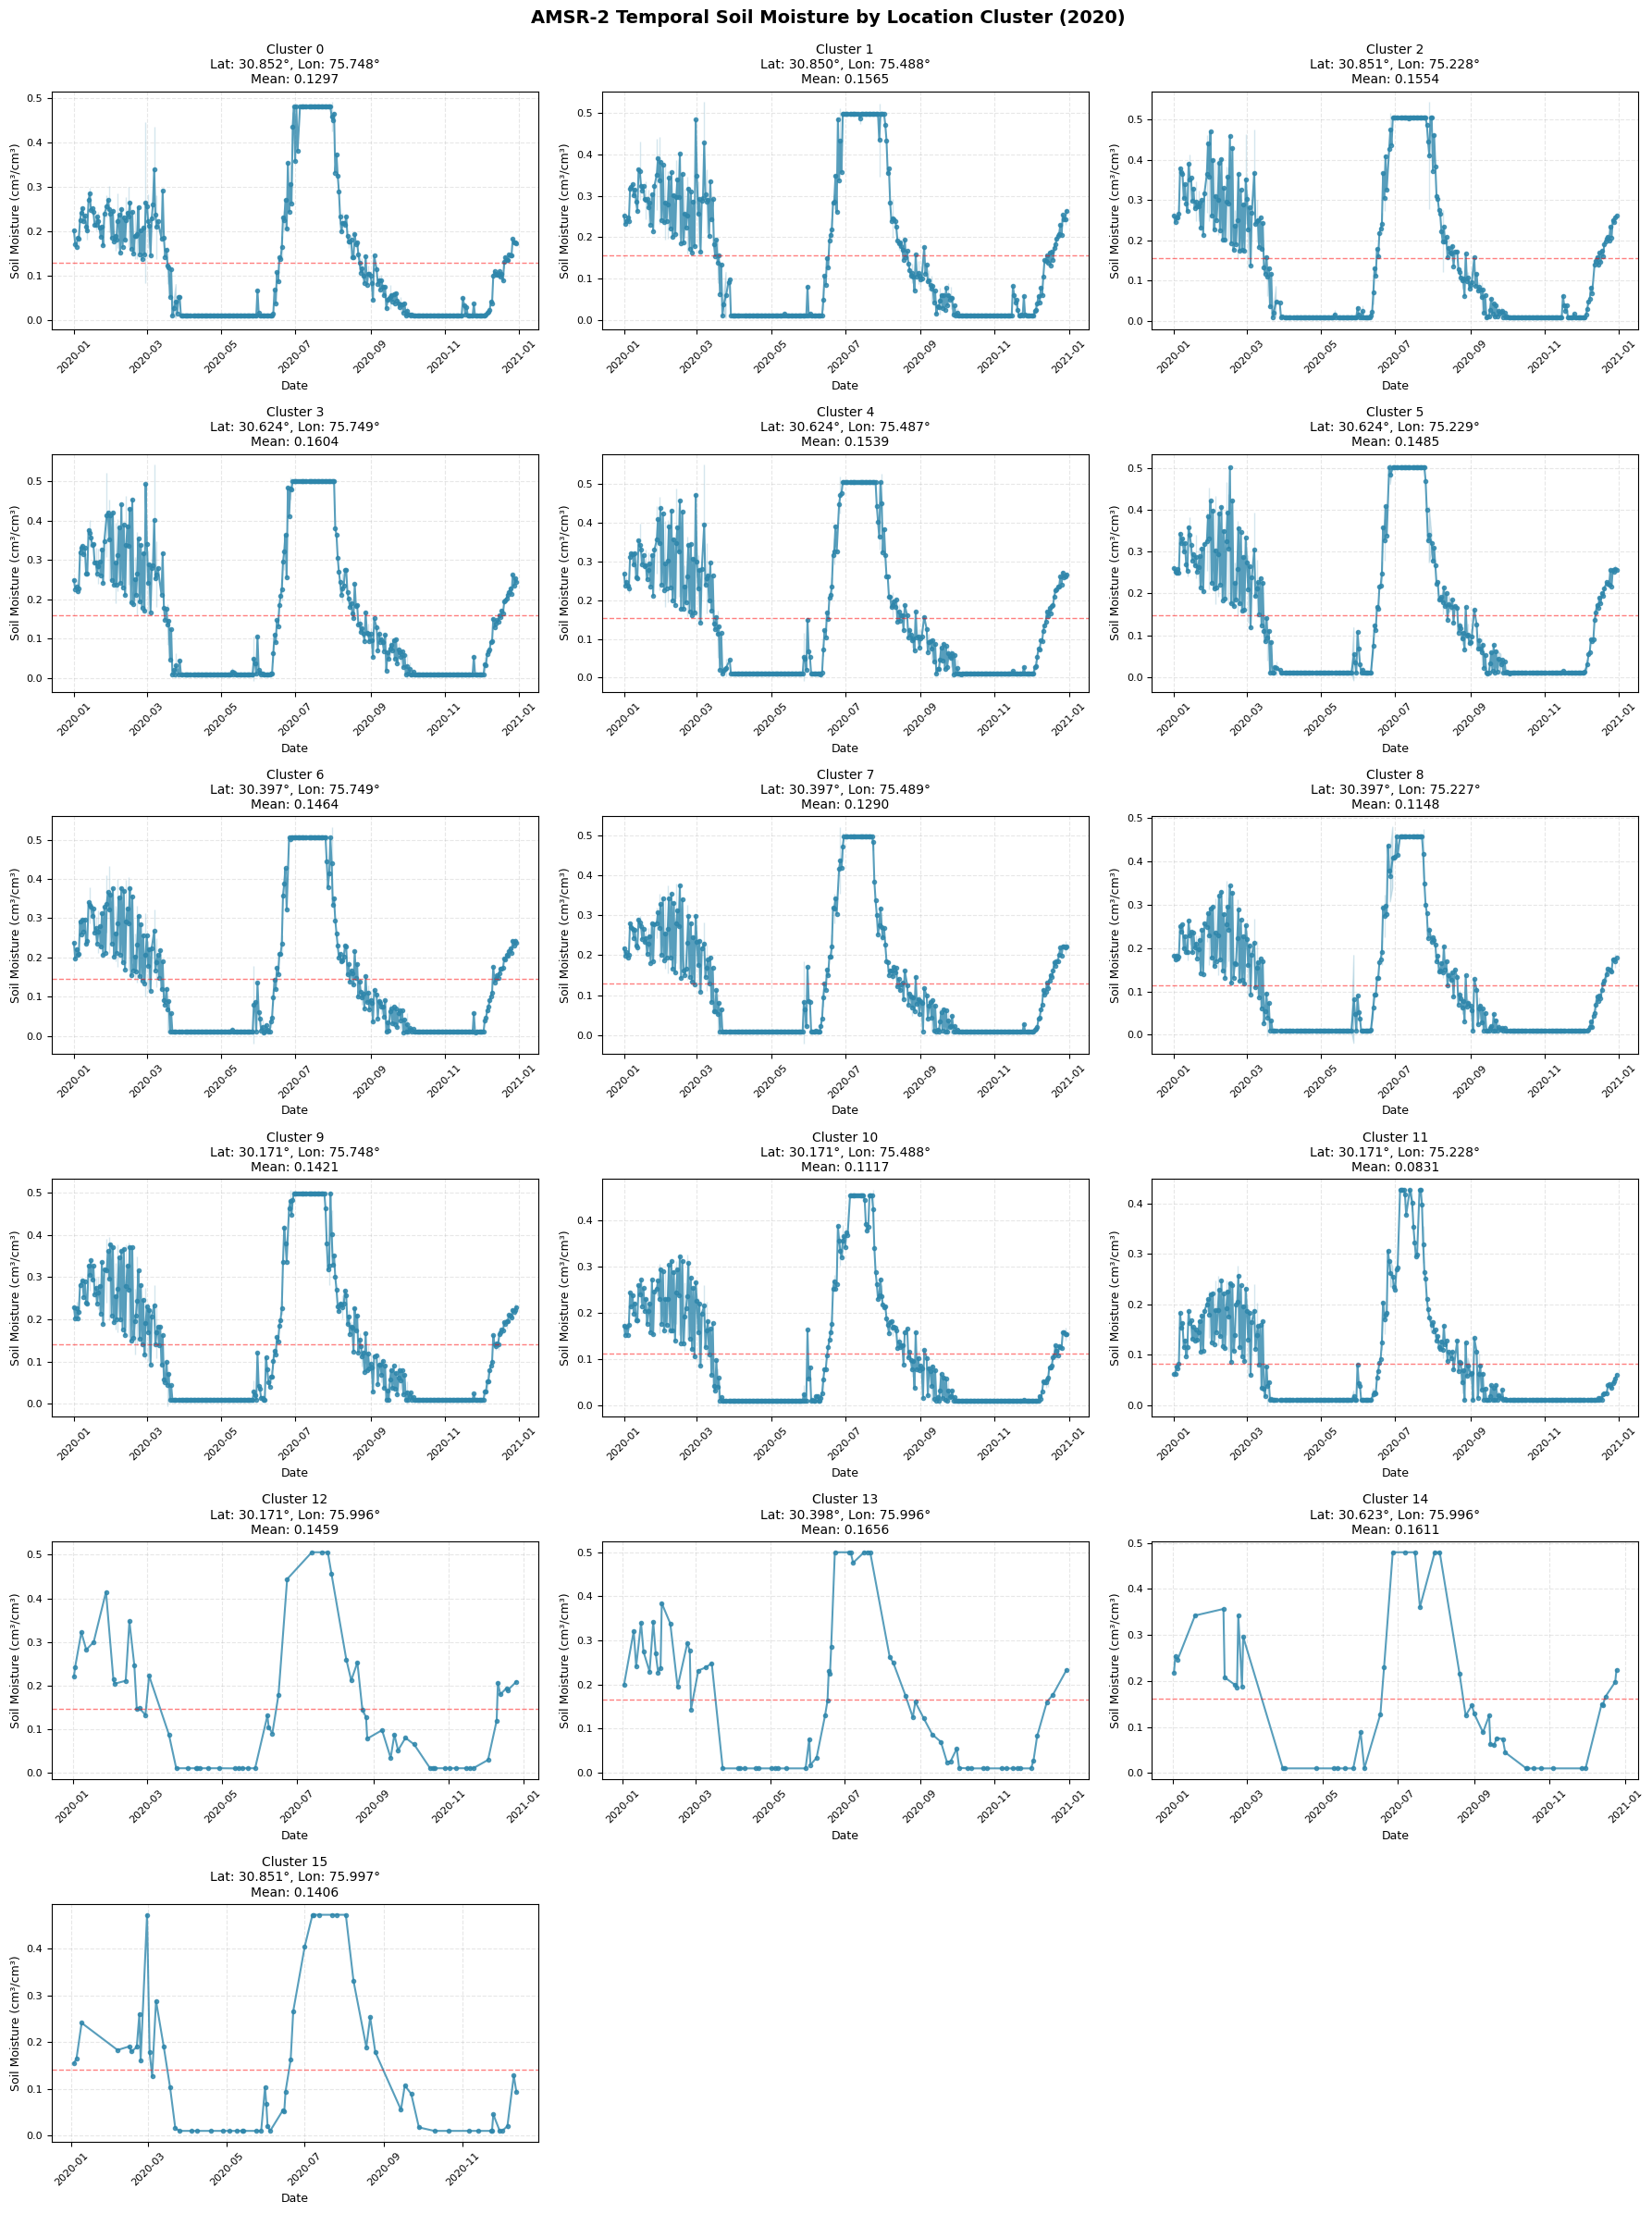


✓ Plot saved as 'AMSR2_cluster_temporal_analysis.png'


In [104]:
# Get unique clusters
clusters = sorted(cluster_time_series['cluster'].unique())
n_clusters_to_plot = len(clusters)

print(f"Plotting temporal soil moisture for {n_clusters_to_plot} clusters...")

# Determine grid size for subplots
n_cols = min(3, n_clusters_to_plot)
n_rows = int(np.ceil(n_clusters_to_plot / n_cols))

# Create figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
if n_clusters_to_plot == 1:
    axes = np.array([axes])
axes = axes.flatten()

# Plot each cluster
for idx, cluster_id in enumerate(clusters):
    ax = axes[idx]
    
    # Get data for this cluster
    cluster_data = cluster_time_series[cluster_time_series['cluster'] == cluster_id].copy()
    cluster_data = cluster_data.sort_values('date')
    
    # Get centroid coordinates
    centroid_info = cluster_centroids[cluster_centroids['cluster'] == cluster_id]
    if len(centroid_info) > 0:
        centroid_lat = centroid_info['centroid_lat'].values[0]
        centroid_lon = centroid_info['centroid_lon'].values[0]
    else:
        centroid_lat = centroid_lon = 0
    
    # Plot
    ax.plot(cluster_data['date'], cluster_data['sm_mean'], 
            marker='o', markersize=3, linewidth=1.5, alpha=0.8, color='#2E86AB')
    
    # Add error bars if std is available
    if cluster_data['sm_std'].notna().any():
        ax.fill_between(cluster_data['date'], 
                        cluster_data['sm_mean'] - cluster_data['sm_std'],
                        cluster_data['sm_mean'] + cluster_data['sm_std'],
                        alpha=0.2, color='#2E86AB')
    
    # Add mean line
    mean_sm = cluster_data['sm_mean'].mean()
    ax.axhline(y=mean_sm, color='red', linestyle='--', linewidth=1, alpha=0.5)
    
    # Formatting
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('Soil Moisture (cm³/cm³)', fontsize=9)
    ax.set_title(f'Cluster {cluster_id}\nLat: {centroid_lat:.3f}°, Lon: {centroid_lon:.3f}°\nMean: {mean_sm:.4f}', 
                fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

# Hide empty subplots
for idx in range(n_clusters_to_plot, len(axes)):
    axes[idx].axis('off')

plt.suptitle('AMSR-2 Temporal Soil Moisture by Location Cluster (2020)', 
            fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('AMSR2_cluster_temporal_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Plot saved as 'AMSR2_cluster_temporal_analysis.png'")

## Plot All Clusters on Single Plot (Overlay)

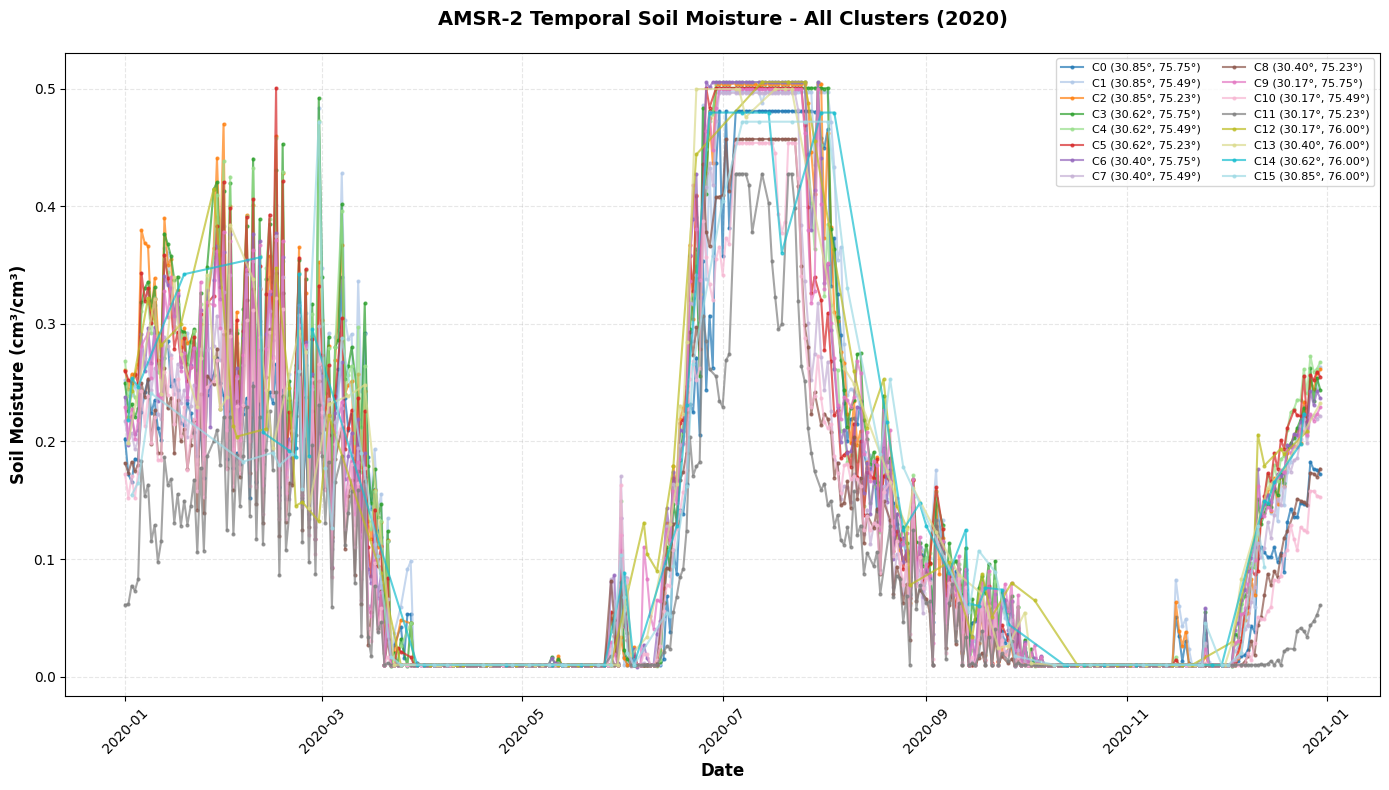

✓ Plot saved as 'AMSR2_all_clusters_overlay.png'


In [105]:
# Create a single plot with all clusters overlaid
fig, ax = plt.subplots(figsize=(14, 8))

# Generate color palette
colors = plt.cm.tab20(np.linspace(0, 1, min(len(clusters), 20)))
if len(clusters) > 20:
    colors = plt.cm.hsv(np.linspace(0, 1, len(clusters)))

# Plot each cluster
for idx, cluster_id in enumerate(clusters):
    cluster_data = cluster_time_series[cluster_time_series['cluster'] == cluster_id].copy()
    cluster_data = cluster_data.sort_values('date')
    
    # Get centroid
    centroid_info = cluster_centroids[cluster_centroids['cluster'] == cluster_id]
    if len(centroid_info) > 0:
        centroid_lat = centroid_info['centroid_lat'].values[0]
        centroid_lon = centroid_info['centroid_lon'].values[0]
        label = f'C{cluster_id} ({centroid_lat:.2f}°, {centroid_lon:.2f}°)'
    else:
        label = f'Cluster {cluster_id}'
    
    # Plot
    ax.plot(cluster_data['date'], cluster_data['sm_mean'], 
            marker='o', markersize=2, linewidth=1.5, alpha=0.7, 
            color=colors[idx % len(colors)], label=label)

# Formatting
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Soil Moisture (cm³/cm³)', fontsize=12, fontweight='bold')
ax.set_title('AMSR-2 Temporal Soil Moisture - All Clusters (2020)', 
            fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(axis='x', rotation=45)

# Add legend (limit to first 20 if too many clusters)
if len(clusters) <= 20:
    ax.legend(fontsize=8, loc='best', ncol=2)
else:
    ax.legend(fontsize=7, loc='best', ncol=3, framealpha=0.8)

plt.tight_layout()
plt.savefig('AMSR2_all_clusters_overlay.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Plot saved as 'AMSR2_all_clusters_overlay.png'")

## Cluster Statistics Summary

In [106]:
# Create summary statistics for each cluster
cluster_summary = []

for cluster_id in clusters:
    cluster_data = df_clustered[df_clustered['cluster'] == cluster_id]
    time_series = cluster_time_series[cluster_time_series['cluster'] == cluster_id]
    
    # Get centroid
    centroid_info = cluster_centroids[cluster_centroids['cluster'] == cluster_id]
    if len(centroid_info) > 0:
        centroid_lat = centroid_info['centroid_lat'].values[0]
        centroid_lon = centroid_info['centroid_lon'].values[0]
    else:
        centroid_lat = centroid_lon = np.nan
    
    summary = {
        'Cluster': cluster_id,
        'Centroid_Lat': centroid_lat,
        'Centroid_Lon': centroid_lon,
        'N_Locations': cluster_data[['latitude', 'longitude']].drop_duplicates().shape[0],
        'N_Observations': len(cluster_data),
        'SM_Mean': cluster_data['soil_moisture'].mean(),
        'SM_Std': cluster_data['soil_moisture'].std(),
        'SM_Min': cluster_data['soil_moisture'].min(),
        'SM_Max': cluster_data['soil_moisture'].max(),
        'N_Days': time_series['date'].nunique()
    }
    cluster_summary.append(summary)

summary_df = pd.DataFrame(cluster_summary)

print("="*80)
print("CLUSTER SUMMARY STATISTICS")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)

# Save summary to CSV
summary_file = 'AMSR2_cluster_summary.csv'
summary_df.to_csv(summary_file, index=False)
print(f"\n✓ Summary saved to '{summary_file}'")

CLUSTER SUMMARY STATISTICS
 Cluster  Centroid_Lat  Centroid_Lon  N_Locations  N_Observations  SM_Mean   SM_Std   SM_Min   SM_Max  N_Days
       0     30.851611     75.747919          446             446 0.130505 0.143967 0.009888 0.481056     357
       1     30.850488     75.488182          445             445 0.156546 0.163590 0.009282 0.497531     358
       2     30.850854     75.228275          441             441 0.155505 0.167314 0.009096 0.504324     352
       3     30.624141     75.748545          444             444 0.160655 0.167604 0.008878 0.500716     356
       4     30.624063     75.487483          442             442 0.154068 0.163887 0.008822 0.505458     354
       5     30.624077     75.228707          429             429 0.148312 0.159596 0.009642 0.500594     341
       6     30.397121     75.748524          448             448 0.147177 0.158551 0.008306 0.505611     359
       7     30.397050     75.489274          443             443 0.129281 0.145688 0.009106 

## Load Precipitation Data

In [107]:
def read_precipitation_data(file_path, target_lon, target_lat):
    """
    Read precipitation data from IMERG CSV file and extract time series for target point.
    """
    print(f"\nReading precipitation data from: {file_path}")
    
    # Read the CSV file
    df = pd.read_csv(file_path)
    
    # Parse time column (format: DD-MM-YYYY HH:MM)
    df['time'] = pd.to_datetime(df['time'], format='%d-%m-%Y %H:%M')
    
    print(f"Precipitation data loaded:")
    print(f"  Total observations: {len(df):,}")
    print(f"  Date range: {df['time'].min()} to {df['time'].max()}")
    print(f"  Unique locations: {df[['longitude', 'latitude']].drop_duplicates().shape[0]:,}")
    
    # Find nearest point to target coordinates
    dlat = df['latitude'] - target_lat
    dlon = df['longitude'] - target_lon
    distances = np.sqrt(dlat**2 + dlon**2)
    min_idx = distances.idxmin()
    nearest_lon = df.loc[min_idx, 'longitude']
    nearest_lat = df.loc[min_idx, 'latitude']
    distance_km = distances.min() * 111
    
    # Extract data for the nearest point
    mask = (df['longitude'] == nearest_lon) & (df['latitude'] == nearest_lat)
    precip_df = df[mask].copy()
    
    # Aggregate to daily (sum precipitation)
    precip_df['date'] = precip_df['time'].dt.date
    precip_daily = precip_df.groupby('date').agg({
        'precipitation': 'sum',
        'time': 'first'
    }).reset_index(drop=True)
    precip_daily['time'] = pd.to_datetime(precip_daily['time'])
    
    print(f"\nPrecipitation point selected:")
    print(f"  Target: ({target_lon:.4f}, {target_lat:.4f})")
    print(f"  Actual: ({nearest_lon:.4f}, {nearest_lat:.4f})")
    print(f"  Distance: {distance_km:.2f} km")
    print(f"  Daily observations: {len(precip_daily):,}")
    
    return precip_daily

# Load precipitation data
if PRECIP_FILE.exists():
    precip_df = read_precipitation_data(PRECIP_FILE, TARGET_LON, TARGET_LAT)
    
    # Filter by date range
    precip_df['date'] = pd.to_datetime(precip_df['time']).dt.date
    precip_filtered = precip_df[
        (precip_df['time'] >= START_DATE) & 
        (precip_df['time'] <= STOP_DATE)
    ].copy()
    
    print(f"\nPrecipitation Date Range Filter:")
    print(f"  Observations in range: {len(precip_filtered):,}")
    if len(precip_filtered) > 0:
        print(f"  Precipitation range: {precip_filtered['precipitation'].min():.4f} to {precip_filtered['precipitation'].max():.4f} mm/day")
        print(f"  Mean precipitation: {precip_filtered['precipitation'].mean():.4f} mm/day")
        print(f"  Total precipitation: {precip_filtered['precipitation'].sum():.2f} mm")
else:
    print(f"WARNING: Precipitation file not found: {PRECIP_FILE}")
    precip_filtered = None


Reading precipitation data from: /home/intern1/my_data/sm2rain-irrigation/IMERG_ROI1_2020.csv


Precipitation data loaded:
  Total observations: 876,000
  Date range: 2020-01-01 00:00:00 to 2020-12-30 23:00:00
  Unique locations: 100

Precipitation point selected:
  Target: (75.5000, 30.5000)
  Actual: (75.5500, 30.4500)
  Distance: 7.85 km
  Daily observations: 365

Precipitation Date Range Filter:
  Observations in range: 365
  Precipitation range: 0.0000 to 155.2600 mm/day
  Mean precipitation: 3.8994 mm/day
  Total precipitation: 1423.28 mm


## Visualize Cluster Locations on Map

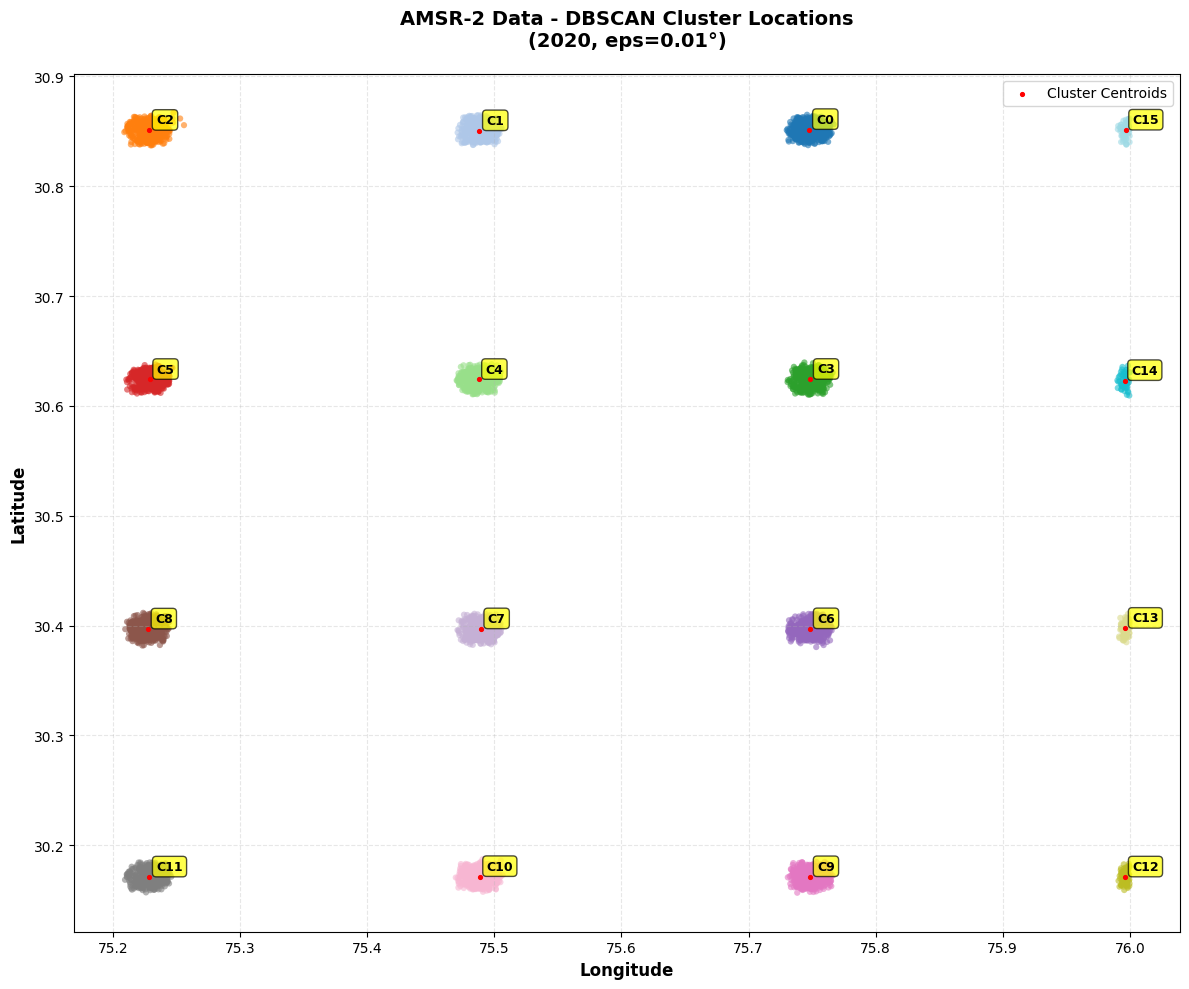

✓ Plot saved as 'AMSR2_cluster_map.png'


In [108]:
# Plot cluster locations
fig, ax = plt.subplots(figsize=(12, 10))

# Plot all points colored by cluster
scatter = ax.scatter(df_clustered['longitude'], df_clustered['latitude'], 
                    c=df_clustered['cluster'], cmap='tab20', 
                    s=20, alpha=0.6, edgecolors='none')

# Plot centroids
ax.scatter(cluster_centroids['centroid_lon'], cluster_centroids['centroid_lat'], 
          marker='.', s=30, c='red', linewidths=1,
          label='Cluster Centroids', zorder=5)

# Add cluster labels
for idx, row in cluster_centroids.iterrows():
    ax.annotate(f'C{int(row["cluster"])}', 
               (row['centroid_lon'], row['centroid_lat']),
               xytext=(5, 5), textcoords='offset points',
               fontsize=9, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# Formatting
ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
ax.set_title('AMSR-2 Data - DBSCAN Cluster Locations\n(2020, eps=0.01°)', 
            fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=10)

# Add colorbar
# cbar = plt.colorbar(scatter, ax=ax, label='Cluster ID')
# cbar.set_label('Cluster ID', fontsize=11)

plt.tight_layout()
plt.savefig('AMSR2_cluster_map.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Plot saved as 'AMSR2_cluster_map.png'")

## Summary

This notebook has successfully:
1. Loaded AMSR-2 soil moisture data from CSV
2. Identified unique location coordinates
3. Applied DBSCAN clustering with tolerance = 0.01 degrees (~1.1 km)
4. Grouped nearby points into clusters (treating each cluster as one location)
5. Calculated temporal soil moisture patterns for each cluster
6. Generated visualization plots:
   - Individual time series for each cluster
   - Overlay plot with all clusters
   - Spatial map showing cluster locations

The DBSCAN algorithm automatically identifies spatial clusters of measurement points, treating points within the tolerance distance as belonging to the same location. This handles the case where multiple observations exist at slightly different coordinates due to satellite positioning variations.

### Plot Temporal Soil Moisture for Selected Location

In [109]:
# Calculate distances from target to all cluster centroids
cluster_centroids['distance_from_target'] = np.sqrt(
    (cluster_centroids['centroid_lat'] - TARGET_LAT)**2 + 
    (cluster_centroids['centroid_lon'] - TARGET_LON)**2
)

# Convert to km (approximate)
cluster_centroids['distance_km'] = cluster_centroids['distance_from_target'] * 111

# Find clusters within tolerance
nearby_clusters = cluster_centroids[cluster_centroids['distance_from_target'] <= SEARCH_TOLERANCE].copy()
nearby_clusters = nearby_clusters.sort_values('distance_from_target')

if len(nearby_clusters) == 0:
    print(f"\n⚠ No clusters found within {SEARCH_TOLERANCE}° tolerance!")
    print(f"\nClosest cluster:")
    closest = cluster_centroids.nsmallest(1, 'distance_from_target').iloc[0]
    print(f"  Cluster ID: {int(closest['cluster'])}")
    print(f"  Location: ({closest['centroid_lat']:.4f}°, {closest['centroid_lon']:.4f}°)")
    print(f"  Distance: {closest['distance_km']:.2f} km")
    print(f"\nConsider increasing SEARCH_TOLERANCE to at least {closest['distance_from_target']:.3f}°")
    nearest_cluster_id = int(closest['cluster'])
    nearest_distance = closest['distance_km']
    nearest_lat = closest['centroid_lat']
    nearest_lon = closest['centroid_lon']
else:
    print(f"\n✓ Found {len(nearby_clusters)} cluster(s) within tolerance:")
    for idx, row in nearby_clusters.head(5).iterrows():
        print(f"  Cluster {int(row['cluster'])}: ({row['centroid_lat']:.4f}°, {row['centroid_lon']:.4f}°) - {row['distance_km']:.2f} km away")
    
    # Select the nearest cluster
    nearest_cluster_id = int(nearby_clusters.iloc[0]['cluster'])
    nearest_distance = nearby_clusters.iloc[0]['distance_km']
    nearest_lat = nearby_clusters.iloc[0]['centroid_lat']
    nearest_lon = nearby_clusters.iloc[0]['centroid_lon']
    
    print(f"\n✓ Nearest cluster selected:")
    print(f"  Cluster ID: {nearest_cluster_id}")
    print(f"  Centroid: ({nearest_lat:.4f}°, {nearest_lon:.4f}°)")
    print(f"  Distance from target: {nearest_distance:.2f} km")


⚠ No clusters found within 0.1° tolerance!

Closest cluster:
  Cluster ID: 7
  Location: (30.3971°, 75.4893°)
  Distance: 11.49 km

Consider increasing SEARCH_TOLERANCE to at least 0.104°


### Find Nearest Cluster

In [110]:
# Specify target coordinates
TARGET_LAT = 30.5
TARGET_LON = 75.5
SEARCH_TOLERANCE = 0.1  # degrees (~11 km)

print(f"Searching for nearest cluster to:")
print(f"  Target: ({TARGET_LAT}°, {TARGET_LON}°)")
print(f"  Search tolerance: {SEARCH_TOLERANCE}° (~{SEARCH_TOLERANCE * 111:.1f} km)")

Searching for nearest cluster to:
  Target: (30.5°, 75.5°)
  Search tolerance: 0.1° (~11.1 km)


## Query Specific Location - Temporal Plot

Specify a target coordinate and get the temporal plot for the nearest cluster.


Cluster Information:
  Cluster ID: 7
  Centroid: (30.3971°, 75.4893°)
  Distance from target: 11.49 km
  Number of unique locations: 443
  Total observations: 443
  Days with data: 356

Soil Moisture Statistics:
  Mean: 0.1293 cm³/cm³
  Std Dev: 0.1457 cm³/cm³
  Min: 0.0091 cm³/cm³
  Max: 0.4963 cm³/cm³


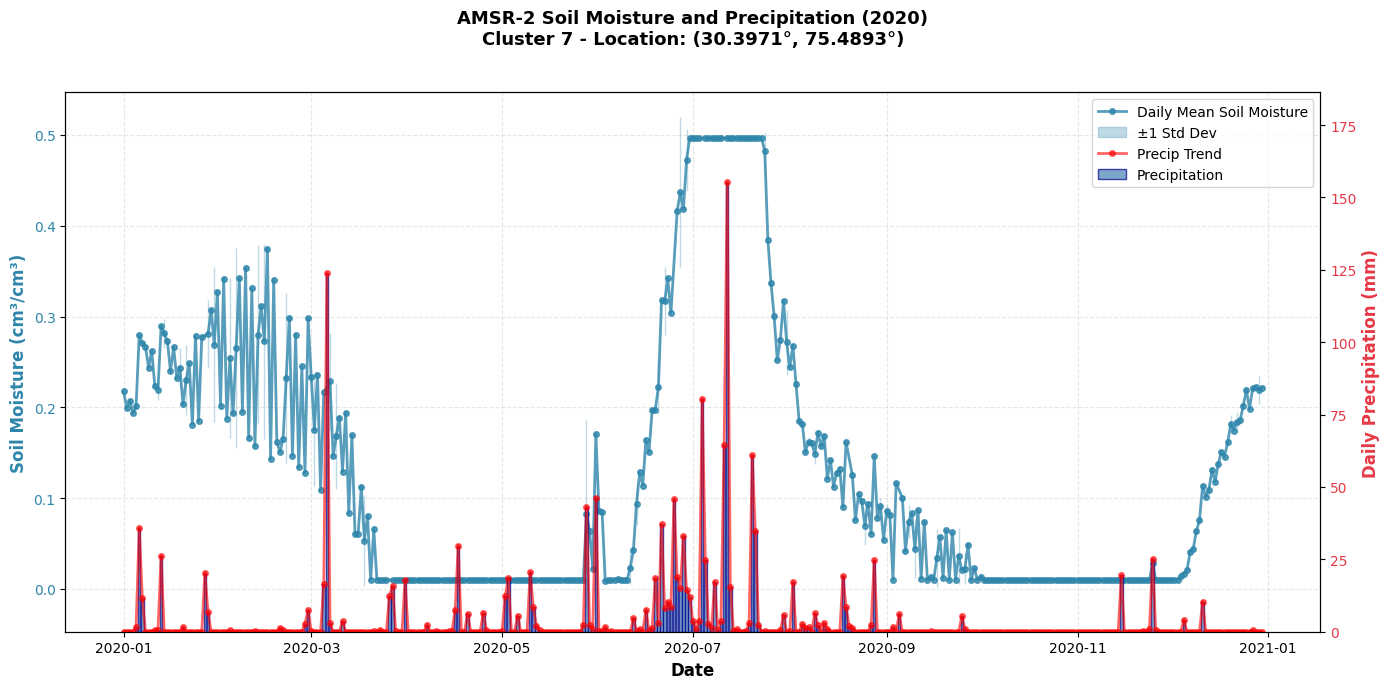


✓ Plot saved as 'AMSR2_cluster_7_temporal.png'


In [113]:
# Get time series data for the nearest cluster
selected_cluster_data = cluster_time_series[cluster_time_series['cluster'] == nearest_cluster_id].copy()
selected_cluster_data = selected_cluster_data.sort_values('date')

# Get cluster information
selected_cluster_info = cluster_centroids[cluster_centroids['cluster'] == nearest_cluster_id].iloc[0]

# Get summary statistics
cluster_stats = summary_df[summary_df['Cluster'] == nearest_cluster_id].iloc[0]

print(f"\nCluster Information:")
print(f"  Cluster ID: {nearest_cluster_id}")
print(f"  Centroid: ({selected_cluster_info['centroid_lat']:.4f}°, {selected_cluster_info['centroid_lon']:.4f}°)")
print(f"  Distance from target: {nearest_distance:.2f} km")
print(f"  Number of unique locations: {int(cluster_stats['N_Locations'])}")
print(f"  Total observations: {int(cluster_stats['N_Observations'])}")
print(f"  Days with data: {int(cluster_stats['N_Days'])}")
print(f"\nSoil Moisture Statistics:")
print(f"  Mean: {cluster_stats['SM_Mean']:.4f} cm³/cm³")
print(f"  Std Dev: {cluster_stats['SM_Std']:.4f} cm³/cm³")
print(f"  Min: {cluster_stats['SM_Min']:.4f} cm³/cm³")
print(f"  Max: {cluster_stats['SM_Max']:.4f} cm³/cm³")

# Create the plot with dual y-axes
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot soil moisture on primary y-axis
color_sm = '#2E86AB'
ax1.plot(selected_cluster_data['date'], selected_cluster_data['sm_mean'], 
        marker='o', markersize=4, linewidth=2, color=color_sm, 
        alpha=0.8, label='Daily Mean Soil Moisture')

# Add error band (standard deviation)
if selected_cluster_data['sm_std'].notna().any():
    ax1.fill_between(selected_cluster_data['date'], 
                    selected_cluster_data['sm_mean'] - selected_cluster_data['sm_std'],
                    selected_cluster_data['sm_mean'] + selected_cluster_data['sm_std'],
                    alpha=0.3, color=color_sm, label='±1 Std Dev')

# Formatting for primary y-axis
ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
ax1.set_ylabel('Soil Moisture (cm³/cm³)', fontsize=12, fontweight='bold', color=color_sm)
ax1.tick_params(axis='y', labelcolor=color_sm)

# Create secondary y-axis for precipitation
if precip_filtered is not None and len(precip_filtered) > 0:
    ax2 = ax1.twinx()
    color_precip = '#E63946'
    
    # Plot precipitation as bars
    ax2.bar(precip_filtered['time'], precip_filtered['precipitation'], 
            color='steelblue', edgecolor='darkblue', alpha=0.7, label='Precipitation')
    
    # Plot precipitation trend line
    ax2.plot(precip_filtered['time'], precip_filtered['precipitation'],
            color='red', marker='o', linewidth=2, markersize=4, alpha=0.6, label='Precip Trend')
    
    # Formatting for secondary y-axis
    ax2.set_ylabel('Daily Precipitation (mm)', fontsize=12, fontweight='bold', color=color_precip)
    ax2.tick_params(axis='y', labelcolor=color_precip)
    
    # Set precipitation axis limit
    ax2.set_ylim(0, precip_filtered['precipitation'].max() * 1.2)
    
    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='upper right')
else:
    ax1.legend(fontsize=10, loc='best')

# Create detailed title
title = f'AMSR-2 Soil Moisture and Precipitation (2020)\n'
title += f'Cluster {nearest_cluster_id} - Location: ({selected_cluster_info["centroid_lat"]:.4f}°, {selected_cluster_info["centroid_lon"]:.4f}°)\n'
# title += f'Distance from target ({TARGET_LAT}°, {TARGET_LON}°): {nearest_distance:.2f} km'
ax1.set_title(title, fontsize=13, fontweight='bold', pad=20)

# Grid and formatting
ax1.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save and display
plt.savefig(f'AMSR2_cluster_{nearest_cluster_id}_temporal.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Plot saved as 'AMSR2_cluster_{nearest_cluster_id}_temporal.png'") 


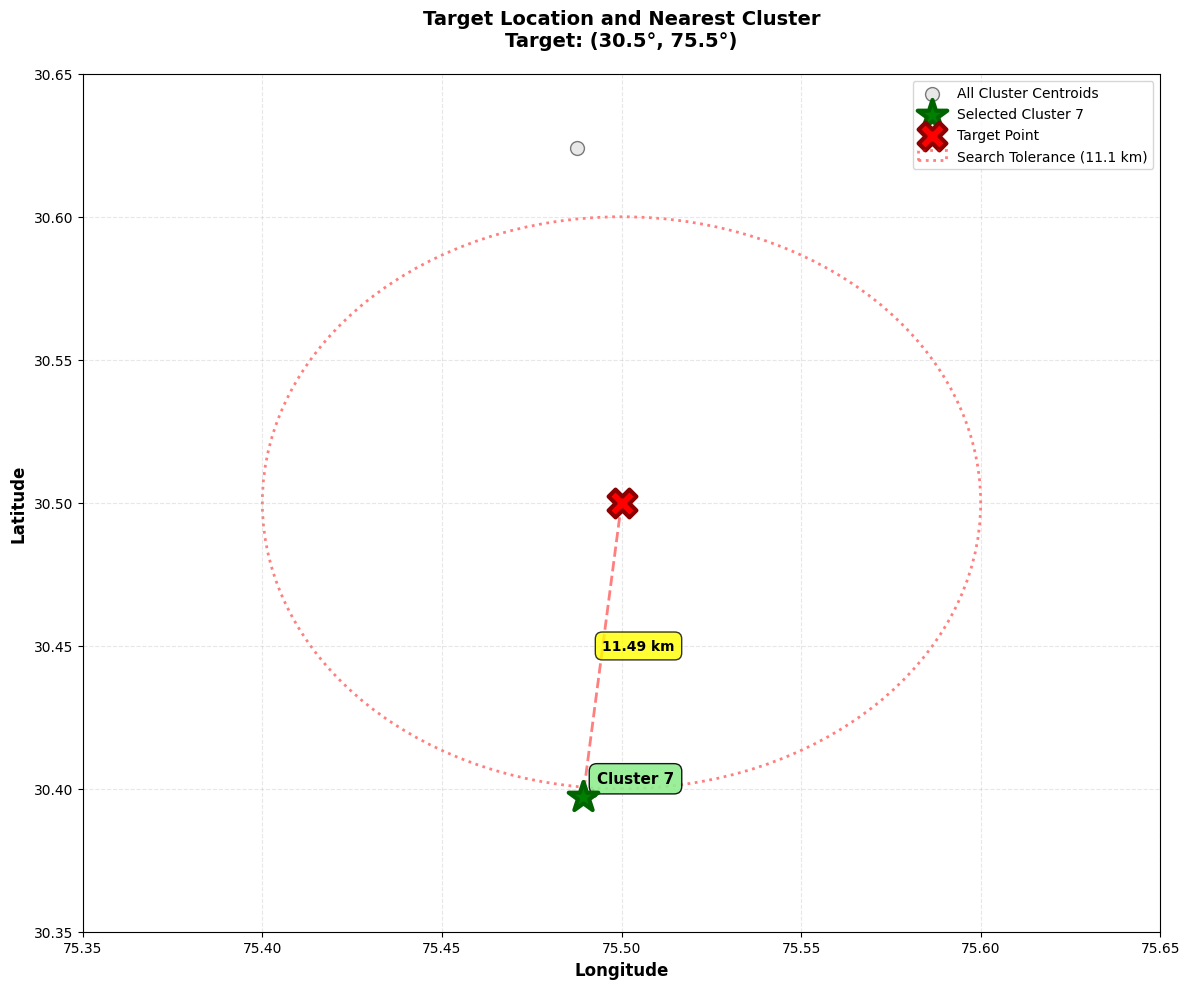

✓ Map saved as 'AMSR2_target_location_map.png'


In [112]:
# Create a map showing the target point and selected cluster
fig, ax = plt.subplots(figsize=(12, 10))

# Plot all cluster centroids
ax.scatter(cluster_centroids['centroid_lon'], cluster_centroids['centroid_lat'], 
          marker='o', s=100, c='lightgray', edgecolors='black', linewidths=1,
          label='All Cluster Centroids', alpha=0.5, zorder=2)

# Plot the selected cluster (larger and highlighted)
selected_centroid = cluster_centroids[cluster_centroids['cluster'] == nearest_cluster_id]
ax.scatter(selected_centroid['centroid_lon'], selected_centroid['centroid_lat'], 
          marker='*', s=500, c='green', edgecolors='darkgreen', linewidths=3,
          label=f'Selected Cluster {nearest_cluster_id}', zorder=4)

# Plot the target point
ax.scatter([TARGET_LON], [TARGET_LAT], 
          marker='X', s=400, c='red', edgecolors='darkred', linewidths=3,
          label='Target Point', zorder=5)

# Draw a line connecting target to selected cluster
ax.plot([TARGET_LON, selected_centroid['centroid_lon'].values[0]], 
       [TARGET_LAT, selected_centroid['centroid_lat'].values[0]], 
       'r--', linewidth=2, alpha=0.5, zorder=3)

# Add distance annotation
mid_lon = (TARGET_LON + selected_centroid['centroid_lon'].values[0]) / 2
mid_lat = (TARGET_LAT + selected_centroid['centroid_lat'].values[0]) / 2
ax.annotate(f'{nearest_distance:.2f} km', 
           xy=(mid_lon, mid_lat), fontsize=10, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8))

# Add cluster label
ax.annotate(f'Cluster {nearest_cluster_id}', 
           (selected_centroid['centroid_lon'].values[0], selected_centroid['centroid_lat'].values[0]),
           xytext=(10, 10), textcoords='offset points',
           fontsize=11, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.9),
           arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=2))

# Draw search tolerance circle (approximate)
from matplotlib.patches import Circle
circle = Circle((TARGET_LON, TARGET_LAT), SEARCH_TOLERANCE, 
               color='red', fill=False, linestyle=':', linewidth=2, 
               alpha=0.5, label=f'Search Tolerance ({SEARCH_TOLERANCE * 111:.1f} km)')
ax.add_patch(circle)

# Formatting
ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
ax.set_title(f'Target Location and Nearest Cluster\nTarget: ({TARGET_LAT}°, {TARGET_LON}°)', 
            fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=10, loc='best')

# Set axis limits to focus on the area of interest
margin = SEARCH_TOLERANCE * 1.5
ax.set_xlim(TARGET_LON - margin, TARGET_LON + margin)
ax.set_ylim(TARGET_LAT - margin, TARGET_LAT + margin)

plt.tight_layout()
plt.savefig(f'AMSR2_target_location_map.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Map saved as 'AMSR2_target_location_map.png'")